In [22]:
import os
import jax
from astropy.table import Table
import numpy as np
import jax.numpy as jnp
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
from dustmaps.config import config
import healpy as hp
import astropy as ap
from astropy.coordinates import SkyCoord
import jax.random as jr
from astropy.io import fits
from hmc_dust.better_hmc import HMCSampler
import jax.scipy.special as jss
import arviz as az
import blackjax
from jax.scipy.stats import t
from jax.scipy.special import logsumexp
from jax.scipy.special import gammaln
from jax.scipy.stats import norm as snorm

from hmc_dust import DATA, GAIA


from pathlib import Path

data_file = Path('../sherlock_results_2/overall_data_Gaia_XP_fitting_actual_data_40345618_combined.npy')
tag = data_file.stem.removeprefix('overall_data_')
# -> 'Gaia_XP_fitting_actual_data_final_run'


INV_GAMMA_MEAN = 9
INV_GAMMA_VAR  = 81
inv_gamma_variance_prior_alpha = INV_GAMMA_MEAN**2/INV_GAMMA_VAR + 2
inv_gamma_variance_prior_beta = INV_GAMMA_MEAN**3/INV_GAMMA_VAR + INV_GAMMA_MEAN
inv_gamma_variance_prior_alpha = jnp.exp(0.1251910775899887)
inv_gamma_variance_prior_beta  = jnp.exp(1.294155478477478)
student_t_sigma = jnp.sqrt(inv_gamma_variance_prior_beta/inv_gamma_variance_prior_alpha)
student_t_nu = 2*inv_gamma_variance_prior_alpha


overall_data_arr = jnp.asarray(np.load(data_file))
accept_prob_arr = jnp.zeros(overall_data_arr[0].size)


RUN = os.environ.get("SLURM_JOB_ID", "local")


def out(name):
    root, ext = os.path.splitext(name)
    return f"{root}_{RUN}{ext}"


fits_table = Table.read(GAIA / "gc_sightline.fits")


gc_builtin = SkyCoord(0*u.deg, 0*u.deg, frame='galactic').icrs


star_coords = SkyCoord(np.asarray(fits_table["ra"])*u.deg, np.asarray(fits_table["dec"])*u.deg)
fits_table["sep_gc_deg"] = star_coords.separation(gc_builtin).deg




plx_np = fits_table["parallax"]              # parallax measurements (mas)
plx = jnp.asarray(np.asarray(plx_np).astype(np.float32))
plx_err_np = fits_table["parallax_err"]         # their uncertainties (mas)
plx_err = jnp.asarray(np.asarray(plx_err_np).astype(np.float32))
ext_np  = fits_table["ext"]                  # extinction
ext = jnp.asarray(np.asarray(ext_np).astype(np.float32))
ext_err_np = fits_table["ext_err"]
ext_err = jnp.asarray(np.asarray(ext_err_np).astype(np.float32))
sep_np = fits_table["sep_gc_deg"]
separation = jnp.asarray(np.asarray(sep_np).astype(np.float32))
print(fits_table.info())


with fits.open(DATA / "mean_and_std_healpix.fits") as hdul:
    hdul.info()
    print(hdul['MEAN'].header['ORDERING'])
    print(hdul['STD.'].header['ORDERING'])
    galactic_center_healpix = hp.pixelfunc.ang2pix(256, theta = 0.0, phi = 0.0, nest = True, lonlat = True)
    mean_along_center = jnp.asarray(hdul["MEAN"].data[:, galactic_center_healpix].astype(np.float32))
    std_along_center  = jnp.asarray(hdul["STD."].data[:, galactic_center_healpix].astype(np.float32))
    radial_centers    = jnp.asarray(hdul["RADIAL PIXEL CENTERS"].data.field(0),    dtype=jnp.float32)
    radial_boundaries = jnp.asarray(hdul["RADIAL PIXEL BOUNDARIES"].data.field(0), dtype=jnp.float32)
    distance_gaps = np.diff(radial_boundaries)


# 1000/x is its own inverse so this fcn is also plx_to_dist
def dist_to_plx(dist):
    return 1000/dist


def get_x_err_basic(plx_err, plx):
    return 1000*(plx**(-2))*plx_err


def logposterior_on_r(r, w, w_err):
    p_w_given_r = -0.5*(w - 1000/r)**2/(w_err**2)
    p_r = distance_logprior(r)
    return p_r + p_w_given_r


def get_x_err_advanced(plx_err, plx):
    x = jnp.linspace(0.1, 100000, 20000)
    log_posterior = logposterior_on_r(x, plx, plx_err)
    y = jnp.exp(log_posterior - jnp.max(log_posterior))
    Z    = jnp.trapezoid(y, x)                    
    mean = jnp.trapezoid(x * y, x) / Z
    var  = jnp.trapezoid((x - mean) ** 2 * y, x) / Z
    return jnp.sqrt(var)


def distance_logprior(r):
    return jnp.where(r > 0, -r/10000 + 2*jnp.log(r), -jnp.inf)








assert mean_along_center.shape == distance_gaps.shape
num_stars = plx.size
distances_psc = dist_to_plx(plx)


linspace = jnp.linspace(0.1, 20000, 500)
x_err_basic = jax.vmap(get_x_err_basic, in_axes=(None, 0))(0.1, 1000/linspace)
x_err_advanced = jax.vmap(get_x_err_advanced, in_axes=(None, 0))(0.1, 1000/linspace)

num_overall_steps = 1100
burn_in = 100
num_dimensions = 600
num_fourier_dimensions = 6000
left_distance_padding = 40
right_distance_padding = 600
doing_burn_in = True
use_NUTS = False
use_blackjax_hmc = False
window_adapt_square_mass_matrix = False



min_distance = radial_boundaries[0] - left_distance_padding
max_distance = radial_boundaries[radial_boundaries.size - 1] + right_distance_padding
dx = (max_distance - min_distance)/(num_dimensions - 1)
integrating_dims_padding_left = 20
integrating_dims_padding_right = 300
total_integrating_dims = integrating_dims_padding_left + integrating_dims_padding_right + num_dimensions
integrating_dust_x_linspace = jnp.arange(num_dimensions + integrating_dims_padding_left + integrating_dims_padding_right)*dx + min_distance - integrating_dims_padding_left*dx
# This is the analouge of fixed_points_linspace
dust_x_linspace = jnp.arange(num_dimensions)*dx + min_distance

fourier_length = dx*(num_fourier_dimensions - 1)
num_fitting_params = 3
omegas = 2*jnp.pi*jnp.fft.fftfreq(num_fourier_dimensions, d = dx)
error_bars_on_data = 0.025


cumulative_integrated_dust = jnp.concatenate(
    [jnp.array([0.0]), jnp.cumsum(mean_along_center * distance_gaps)])


x_obs = dist_to_plx(plx)
y_obs = ext




mask = (separation < 0.3) & (plx - plx_err > 1000/1800) & (plx + plx_err < 1000/40)
x_obs = x_obs[mask]
y_obs = y_obs[mask]
plx_obs = plx[mask]
data_ext_err = ext_err[mask]
data_plx_err = plx_err[mask]
x_error = jax.vmap(get_x_err_basic)(plx_err[mask], plx_obs)
num_data = x_obs.size
inv_cov_data_matrix = jnp.linalg.inv(jnp.diag(ext_err[mask]**2))
inv_cov_plx_matrix = jnp.linalg.inv(jnp.diag(plx_err[mask]**2))


initial_logvar = 4.0
initial_lognu = 0
initial_offset = -7.6


logvar_prior_mean = initial_logvar
lognu_prior_mean = 0.0
offset_prior_mean = initial_offset


normalization_factor = num_fourier_dimensions/jnp.sqrt(fourier_length)
omegas = 2*jnp.pi*jnp.fft.fftfreq(num_fourier_dimensions, d = dx)
fixed_logscale = jnp.log(2*(max_distance - min_distance))
dust_x_linspace = jnp.arange(num_dimensions)*dx + min_distance
num_good_samples = 5000
time_arr = jnp.arange(num_good_samples)
num_integration_steps = 20000
initial_step_size = 0.00006
step_size = initial_step_size


def hartley(x):
    fft = jnp.fft.fft(x)
    return jnp.real(fft) - jnp.imag(fft)

def logvarprior(logvar):
    return -0.5*(logvar - logvar_prior_mean)**2
def lognuprior(lognu):
    return -0.5*(lognu - lognu_prior_mean)**2
def logoffsetprior(offset):
    return -0.5*(offset - offset_prior_mean)**2

def inv_gamma_logpdf(x, alpha, beta):
    # β^α / Γ(α) * x^(-α-1) * exp(-β/x),  x > 0
    return jnp.where(
        x > 0,
        alpha * jnp.log(beta) - gammaln(alpha) - (alpha + 1.0) * jnp.log(x) - beta / x,
        -jnp.inf,
    )

def cumulative_trapezoid(y, dx):
    seg = dx * (y[:-1] + y[1:]) / 2.0            # area of each trapezoid segment
    return jnp.concatenate([jnp.zeros(1, y.dtype), jnp.cumsum(seg)])

def average_chi_2_based_on_extinction(r, extinction, x_field, y_field, inverse_data_cov):
    def single(r_i, y_field_i):
        model_at_stars = jnp.interp(r_i, x_field, y_field_i)
        residual = extinction - model_at_stars
        return residual.T @ inverse_data_cov @ residual
    return jnp.average(jax.vmap(single, in_axes=(0, 0))(r, y_field))/extinction.size


def average_chi_2_based_on_r(r, plx_obs, inv_plx_cov):
    def single(r_i):
        residual = dist_to_plx(r_i) - plx_obs
        return residual.T @ inv_plx_cov @ residual
    return jnp.average(jax.vmap(single, in_axes = (0,))(r))/plx_obs.size

def exponentiated_integrated_density(logdensity):
    density = jnp.exp(logdensity)
    return cumulative_trapezoid(density, dx)


def response_function(xi, r, inference_params, offset):
    field = fft_field_hartley(xi, inference_params) + offset
    exp_int_field = exponentiated_integrated_density(field)
    return jnp.interp(r, dust_x_linspace, exp_int_field)


def general_matern_spectral_density(omega, inference_params, jitter = 1e-6):
        logvar, lognu = inference_params
        #logvar, lognu = 5.0, jnp.log(0.475)
        logscale = fixed_logscale
        nu = jnp.exp(lognu)
        log_ratio = jss.gammaln(nu + 0.5) - jss.gammaln(nu)
        r = jnp.square(omega) * jnp.exp(2 * logscale - jnp.log(2.0) - lognu)
        logdensity = logvar + log_ratio - 0.5*jnp.log(2*nu) + logscale - (nu + 0.5)*jnp.log1p(r)
        result = 2*jnp.sqrt(jnp.pi)*jnp.exp(logdensity)
        return jnp.where(omega > 0, result, result * (1.0 + jitter))


def matern_magnitude(omegas, inference_params):
     return jnp.sqrt(general_matern_spectral_density(omegas, inference_params))


def negative_logdensity(x):
    logvar = x[0]
    lognu = x[1]
    offset = x[2]
    xi = x[3:3 + num_fourier_dimensions]
    r = x[3 + num_fourier_dimensions:]
    # hardcoded r back to fixed values
    #r = x_obs_true
    inference_params = (logvar, lognu)
    # There are priors on everything: logvar, lognu, offset, xi, and r
    negative_log_p_s = -logvarprior(logvar) - lognuprior(lognu) - logoffsetprior(offset) + 0.5*xi.T @ xi - jnp.sum(distance_logprior(r))
    field_res = y_obs - response_function(xi, r, inference_params, offset)
    plx_res = plx_obs - dist_to_plx(r)


    field_t_scores = field_res/ext_err[mask]
    log_data_likelihoods = t.logpdf(field_t_scores, df = student_t_nu, loc = 0.0, scale = student_t_sigma)




    # P(all data given field, params, distance) is now the probability of observing the extinctions (first term) times the probabilty of observing the correct distances (second term)
    negative_log_p_d_given_s = -1*jnp.sum(log_data_likelihoods) + 0.5*plx_res.T @ inv_cov_plx_matrix @ plx_res
    return negative_log_p_s + negative_log_p_d_given_s


def fft_field_hartley(noise, inference_params):
    size = noise.shape[0]
    raw_average_amplitude_data = matern_magnitude(omegas, inference_params)
    H = noise * raw_average_amplitude_data          # elementwise, whole array, in order
    y_data = (hartley(H) / size) * normalization_factor
    return y_data[0:num_dimensions]

<Table length=54602>
     name       dtype 
-------------- -------
gdr3_source_id   int64
            ra float32
           dec float32
      parallax float32
  parallax_err float32
           ext float32
       ext_err float32
        teff_K float32
           feh float32
          logg float32
  plx_over_err float32
    sep_gc_deg float64
None
Filename: /home/dtfrake/hmc-dust/Data_And_Samplers/mean_and_std_healpix.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   ()      
  1  MEAN          1 ImageHDU        19   (786432, 516)   float32   
  2  STD.          1 ImageHDU        19   (786432, 516)   float32   
  3  RADIAL PIXEL CENTERS    1 BinTableHDU     20   516R x 1C   [E]   
  4  RADIAL PIXEL BOUNDARIES    1 BinTableHDU     20   517R x 1C   [E]   
  5  MEAN OF INTEGRATED INNER 68.8 PC    1 ImageHDU        16   (786432,)   float32   
  6  STD. OF INTEGRATED INNER 68.8 PC    1 ImageHDU        16   (786432,)   float32   
NEST


In [23]:
logvars = overall_data_arr[:, 0]
lognus = overall_data_arr[:, 1]
offsets = overall_data_arr[:, 2]
overall_extinction_arr = overall_data_arr[:, 3:3 + num_fourier_dimensions]  
overall_star_location_arr = overall_data_arr[:, 3 + num_fourier_dimensions:]

mean_star_location_arr = overall_star_location_arr.mean(axis=0)
logscales = jnp.zeros_like(logvars)
inference_params = (logvars, lognus)


overall_extinction_arr_raw_before_offsets = jax.vmap(fft_field_hartley, in_axes=(0, 0))(
    overall_extinction_arr, inference_params
)
overall_extinction_arr_raw = overall_extinction_arr_raw_before_offsets + offsets[:, None]
overall_extinction_arr_exp = jax.vmap(exponentiated_integrated_density, in_axes=(0))(
    overall_extinction_arr_raw
)
overall_extinction_arr_raw = overall_extinction_arr_raw[:, 0:num_dimensions]
overall_extinction_arr_exp = overall_extinction_arr_exp[:, 0:num_dimensions]


mean_extinction_raw = overall_extinction_arr_raw.sum(axis=0)/num_good_samples
mean_extinction_exp = jnp.exp(overall_extinction_arr_raw).sum(axis = 0)/num_good_samples
log_mean_extinction_exp = jnp.log(mean_extinction_exp)
mean_extinction_exp_int = overall_extinction_arr_exp.sum(axis=0)/num_good_samples
vars = jnp.exp(logvars)
scales = jnp.exp(logscales)
nus = jnp.exp(lognus)
cov= jnp.cov(overall_data_arr, rowvar = False)


errorbar_linspace = jnp.arange(2000)*0.1 + 0.1
def exact_errorbar_loglike(errorbar_mul, ext_true, ext_obs, sigma):
    logprior = inv_gamma_logpdf(errorbar_mul, inv_gamma_variance_prior_alpha, inv_gamma_variance_prior_beta)
    log_p_ext_obs = snorm.logpdf(ext_obs, loc=ext_true, scale=sigma * jnp.sqrt(errorbar_mul))
    return logprior + log_p_ext_obs

def average_errorbar_loglike(errorbar_mul, ext_true_arr, ext_obs, sigma):
    loglike_arr = jax.vmap(exact_errorbar_loglike, in_axes=(None, 0, None, None))(
        errorbar_mul, ext_true_arr, ext_obs, sigma
    )
    return logsumexp(loglike_arr) - jnp.log(ext_true_arr.shape[0])


def exact_position_loglike(index, plx_obs, plx_err, ext_obs, ext_err, field):
    # ext_true is the exponentiated integrated field
    r_exact = integrating_dust_x_linspace[index]
    n = field.shape[0]
    idx = jnp.clip(index - integrating_dims_padding_left, 0, n - 1)
    ext_true = field[idx]
    ext_t_score = (ext_obs - ext_true)/ext_err
    log_ext_likelihood = t.logpdf(ext_t_score, df = student_t_nu, loc = 0.0, scale = student_t_sigma)
    log_x_likelihood = distance_logprior(r_exact) - 0.5*((dist_to_plx(r_exact) - plx_obs)/plx_err)**2
    return log_ext_likelihood + log_x_likelihood




idx = jnp.clip(jnp.arange(total_integrating_dims) - integrating_dims_padding_left,
               0, num_dimensions - 1)
r_grid = integrating_dust_x_linspace[:total_integrating_dims]


# [P, S], sample-independent -- computed once
log_x = (distance_logprior(r_grid)[:, None]
         - 0.5 * ((dist_to_plx(r_grid)[:, None] - plx_obs[None, :]) / data_plx_err[None, :])**2)


@jax.jit
def accumulate(fields):                      # fields: [N_samples, num_dimensions]
    def body(acc, field):
        ext_true = field[idx]                                     # [P]
        tscore = (y_obs[None, :] - ext_true[:, None]) / data_ext_err[None, :]
        ll = t.logpdf(tscore, df=student_t_nu, loc=0.0, scale=student_t_sigma) + log_x
        return jnp.logaddexp(acc, ll), None
    init = jnp.full((total_integrating_dims, y_obs.size), -jnp.inf)
    log_sum, _ = jax.lax.scan(body, init, fields)
    return log_sum - jnp.log(fields.shape[0])


log_mean = accumulate(overall_extinction_arr_exp)




star_posterior_2d = jnp.exp(log_mean)          
dx = integrating_dust_x_linspace[1] - integrating_dust_x_linspace[0]
star_posterior_2d /= (star_posterior_2d.sum(axis=0, keepdims=True) * dx)


x = integrating_dust_x_linspace[:star_posterior_2d.shape[0]]
mean_star_location_arr_analytic = (x @ star_posterior_2d) / star_posterior_2d.sum(axis=0)   # [NUM_STARS]

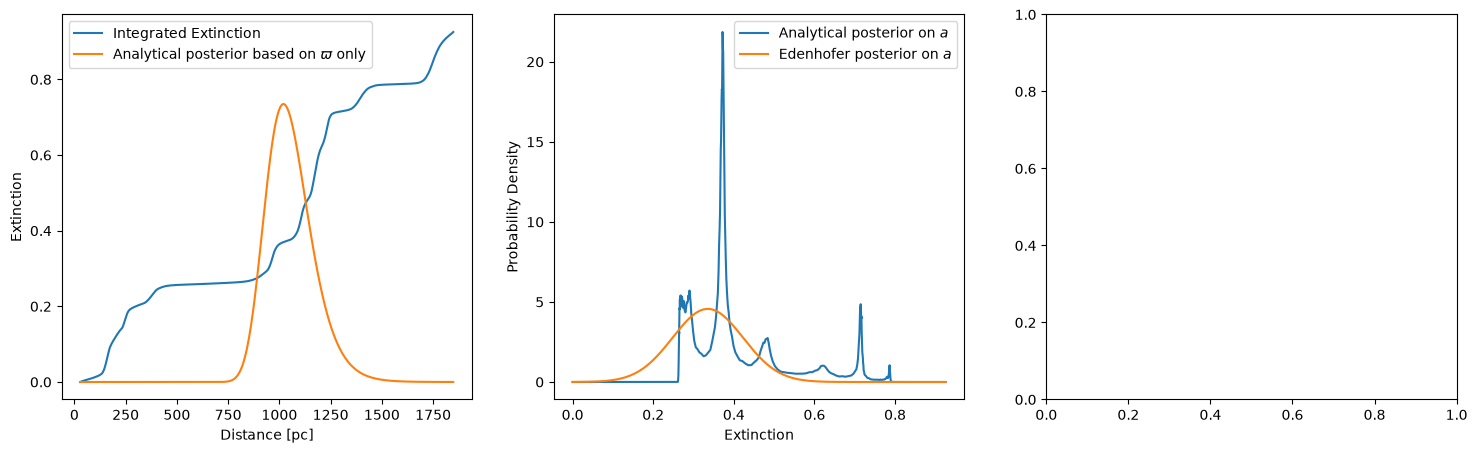

In [30]:
from scipy.stats import norm
fig, axes = plt.subplots(1, 3, figsize = (18, 5))
axes[0].plot(dust_x_linspace, mean_extinction_exp_int, label = "Integrated Extinction")
w_obs = 1
w_err = 0.1

# Returns P(a | p, Dw) at all points along mean_extinction_exp_int
# mean_extinction_exp_int is the integrated version of mean_extinction_exp
def p_a_given_p_Dw_exact(w_obs, w_err):
    d_array = dust_x_linspace
    return p_d_given_Dw(d_array, w_obs, w_err)/mean_extinction_exp


def logposterior_on_r(r, w, w_err):
    p_w_given_r = -0.5*(w - 1000/r)**2/(w_err**2) 
    p_r = distance_logprior(r)
    return p_r + p_w_given_r

def edenhofer_log_posterior_on_r(r, w, w_err):
    return norm.pdf(1/r, loc = w, scale = w_err)
def distance_logprior(r):
    return jnp.where(r > 0, -r/10000 + 2*jnp.log(r), -jnp.inf)

def p_d_given_Dw(d, w_obs, w_err):
    return jnp.exp(logposterior_on_r(d, w_obs, w_err))

def edenhofer_first_moment(w, w_err):
    return jnp.sum(edenhofer_log_posterior_on_r(dust_x_linspace, w, w_err)*mean_extinction_exp_int)/jnp.sum(edenhofer_log_posterior_on_r(dust_x_linspace, w, w_err))

def edenhofer_second_moment(w, w_err):
    return jnp.sum(edenhofer_log_posterior_on_r(dust_x_linspace, w, w_err)*mean_extinction_exp_int**2)/jnp.sum(edenhofer_log_posterior_on_r(dust_x_linspace, w, w_err))

def edenhofer_normal_mean(w, w_err):
    return edenhofer_first_moment(w, w_err)

def edenhofer_normal_std(w, w_err):
    return edenhofer_second_moment(w, w_err) - edenhofer_first_moment(w, w_err)**2



exact_posterior_array = p_a_given_p_Dw_exact(w_obs, w_err)
exact_posterior_array = exact_posterior_array/jnp.trapezoid(exact_posterior_array, mean_extinction_exp_int)
exact_position_posterior_array = jnp.exp(logposterior_on_r(dust_x_linspace, w_obs, w_err))
exact_position_posterior_array = exact_position_posterior_array*200/jnp.trapezoid(exact_position_posterior_array, dust_x_linspace)
axes[0].plot(dust_x_linspace, exact_position_posterior_array, label = r"Analytical posterior based on $\varpi$ only")
axes[1].plot(mean_extinction_exp_int, exact_posterior_array, label = "Analytical posterior on $a$")
edenhofer_mean = edenhofer_normal_mean(w_obs, w_err)
edenhofer_std = edenhofer_normal_std(w_obs, w_err)
axes[1].plot(
    mean_extinction_exp_int,
    norm.pdf(mean_extinction_exp_int, loc=edenhofer_mean, scale=edenhofer_std),
    label = "Edenhofer posterior on $a$"
)

axes[0].set_xlabel("Distance [pc]")
axes[0].set_ylabel("Extinction")
axes[1].set_xlabel("Extinction")
axes[1].set_ylabel("Probability Density")
axes[0].legend()
axes[1].legend()
